## 사전학습모델
- ResNet18 사용

### 1. 라이브러리 로드

In [1]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

import requests
from PIL import Image
from io import BytesIO
import os
import random
import shutil

# 사전학습 모델 라이브러리 추가
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

# pip install icrawler
# 웹사이트에서 필요한걸 긁어오는 라이브러리
from icrawler.builtin import BingImageCrawler, BaiduImageCrawler

In [33]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### 2. 사전학습 모델 
- 모델 다운로드 위치를 변경 가능

In [3]:
os.environ['TORCH_HOME'] = './cust_models'

In [4]:
# 사전학습 가중치 선택
weight = ResNet18_Weights.DEFAULT

# 사전학습 모델 불러오기
model = resnet18(weights=weight)

# 이미 파일이 있으면 다시 다운받지 않음

### 3. 전처리 가져오기
- 직접구성했던 transform을 자동 구성

In [5]:
preprocess = weight.transforms()
preprocess

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

### 4.샘플이미지 예측

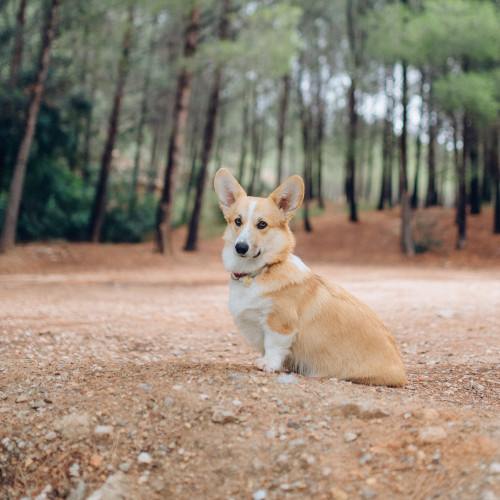

In [6]:
url = 'https://raw.githubusercontent.com/pytorch/vision/main/gallery/assets/dog1.jpg'

response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')
img

In [7]:
input_tensor = preprocess(img)
input_tensor

tensor([[[-0.4568, -0.3883, -0.3369,  ...,  0.0398,  0.0227,  0.0227],
         [-0.4568, -0.3369, -0.1999,  ..., -0.0287,  0.0056,  0.0741],
         [-0.3027, -0.1314, -0.0116,  ..., -0.1143, -0.0458, -0.0116],
         ...,
         [ 0.5364,  0.4508,  0.6221,  ...,  1.1700,  1.2214,  1.1700],
         [ 0.4679,  0.4851,  0.4166,  ...,  1.1529,  1.1358,  1.1015],
         [ 0.3823,  0.3309,  0.2624,  ...,  1.1015,  1.0844,  1.0844]],

        [[-0.2150, -0.1275, -0.0224,  ...,  0.4853,  0.5028,  0.5203],
         [-0.1450, -0.0049,  0.1702,  ...,  0.4503,  0.5028,  0.5728],
         [ 0.0651,  0.2577,  0.3627,  ...,  0.3627,  0.4328,  0.4853],
         ...,
         [ 0.1527,  0.1352,  0.0651,  ...,  0.7304,  0.7479,  0.6604],
         [ 0.2752,  0.4503,  0.0826,  ...,  0.7479,  0.6954,  0.6429],
         [ 0.1877,  0.2052, -0.0749,  ...,  0.8004,  0.8179,  0.8179]],

        [[-0.2010, -0.1312, -0.0615,  ...,  0.1651,  0.0779,  0.0605],
         [-0.1487, -0.0441,  0.0605,  ...,  0

In [8]:
input_batch = input_tensor.unsqueeze(0) # 차원 추가
input_batch

tensor([[[[-0.4568, -0.3883, -0.3369,  ...,  0.0398,  0.0227,  0.0227],
          [-0.4568, -0.3369, -0.1999,  ..., -0.0287,  0.0056,  0.0741],
          [-0.3027, -0.1314, -0.0116,  ..., -0.1143, -0.0458, -0.0116],
          ...,
          [ 0.5364,  0.4508,  0.6221,  ...,  1.1700,  1.2214,  1.1700],
          [ 0.4679,  0.4851,  0.4166,  ...,  1.1529,  1.1358,  1.1015],
          [ 0.3823,  0.3309,  0.2624,  ...,  1.1015,  1.0844,  1.0844]],

         [[-0.2150, -0.1275, -0.0224,  ...,  0.4853,  0.5028,  0.5203],
          [-0.1450, -0.0049,  0.1702,  ...,  0.4503,  0.5028,  0.5728],
          [ 0.0651,  0.2577,  0.3627,  ...,  0.3627,  0.4328,  0.4853],
          ...,
          [ 0.1527,  0.1352,  0.0651,  ...,  0.7304,  0.7479,  0.6604],
          [ 0.2752,  0.4503,  0.0826,  ...,  0.7479,  0.6954,  0.6429],
          [ 0.1877,  0.2052, -0.0749,  ...,  0.8004,  0.8179,  0.8179]],

         [[-0.2010, -0.1312, -0.0615,  ...,  0.1651,  0.0779,  0.0605],
          [-0.1487, -0.0441,  

In [9]:
# 예측

model.eval()
model = model.to(device)

input_batch = input_batch.to(device)

with torch.no_grad():
    output = model(input_batch)

output.shape

prob = torch.softmax(output[0], dim = 0)


### 5. 예측 결과 확인

In [10]:
prob = torch.softmax(output[0], dim=0)

top5_prob, top5_catid = torch.topk(prob, 5)

categories = weight.meta['categories']

for i in range(5):
    print(categories[top5_catid[i]], top5_prob[i].item())

Pembroke 0.6056649684906006
dingo 0.2283715158700943
Cardigan 0.11263088881969452
Eskimo dog 0.01059722900390625
kelpie 0.004690277855843306


#### 6. 이미지 다운로드

- dataset/train과 test 폴더 아래
    - dog
    - cat
    - horse

- icrawler.BingImageCrawler를 사용하여 이미지 다운로드

In [11]:
raw_dir = 'raw'
dataset_dir = 'dataset/train'

classes = {
    'dog photo' : 'dog',
    'cat photo' : 'cat',
    'bird photo' : 'bird'
}

num_classes = 3
batch_size = 16
num_epoch = 5
lr = 0.001

In [12]:
for keyword, class_name in classes.items():
    save_dir = os.path.join(dataset_dir, class_name)
    # print(save_dir)
    os.makedirs(save_dir, exist_ok=True)

    crawler = BingImageCrawler(
        storage = {'root_dir' : save_dir}
    )

    crawler.crawl(
        keyword=keyword,
        max_num=100
    )

2026-05-21 14:56:01,483 - INFO - icrawler.crawler - start crawling...
2026-05-21 14:56:01,483 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-05-21 14:56:01,484 - INFO - feeder - thread feeder-001 exit
2026-05-21 14:56:01,487 - INFO - icrawler.crawler - starting 1 parser threads...
2026-05-21 14:56:01,488 - INFO - icrawler.crawler - starting 1 downloader threads...
2026-05-21 14:56:02,254 - INFO - parser - parsing result page https://www.bing.com/images/async?q=dog photo&first=0
2026-05-21 14:56:02,267 - INFO - downloader - skip downloading file 000001.jpg
2026-05-21 14:56:02,269 - INFO - downloader - skip downloading file 000002.jpg
2026-05-21 14:56:02,269 - INFO - downloader - skip downloading file 000003.jpg
2026-05-21 14:56:02,271 - INFO - downloader - skip downloading file 000004.jpg
2026-05-21 14:56:02,271 - INFO - downloader - skip downloading file 000005.jpg
2026-05-21 14:56:02,273 - INFO - downloader - skip downloading file 000006.jpg
2026-05-21 14:56:02,274 - IN

In [13]:
# 테스트 이미지 폴더
# 
test_dir = 'dataset/test'
for keyword, class_name in classes.items():
    save_dir = os.path.join(test_dir, class_name)
    # print(save_dir)
    os.makedirs(save_dir, exist_ok=True)

    crawler = BingImageCrawler(
        storage = {'root_dir' : save_dir}
    )

    crawler.crawl(
        keyword=keyword,
        max_num=100
    )

2026-05-21 14:56:23,526 - INFO - icrawler.crawler - start crawling...
2026-05-21 14:56:23,527 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-05-21 14:56:23,528 - INFO - feeder - thread feeder-001 exit
2026-05-21 14:56:23,530 - INFO - icrawler.crawler - starting 1 parser threads...
2026-05-21 14:56:23,531 - INFO - icrawler.crawler - starting 1 downloader threads...
2026-05-21 14:56:23,947 - INFO - parser - parsing result page https://www.bing.com/images/async?q=dog photo&first=0
2026-05-21 14:56:23,957 - INFO - downloader - skip downloading file 000001.jpg
2026-05-21 14:56:23,959 - INFO - downloader - skip downloading file 000002.jpg
2026-05-21 14:56:23,959 - INFO - downloader - skip downloading file 000003.jpg
2026-05-21 14:56:23,960 - INFO - downloader - skip downloading file 000004.jpg
2026-05-21 14:56:23,961 - INFO - downloader - skip downloading file 000005.jpg
2026-05-21 14:56:23,961 - INFO - downloader - skip downloading file 000006.jpg
2026-05-21 14:56:23,961 - IN

### 7. 커스텀 데이터셋과 일치하도록 마지막층 변경

In [14]:
model.fc

Linear(in_features=512, out_features=1000, bias=True)

In [15]:
# 분류를 3가지만 할 예정

num_classes = 3

model.fc = nn.Linear(
    in_features=model.fc.in_features,
    out_features=num_classes
)

model = model.to(device)
model.fc

Linear(in_features=512, out_features=3, bias=True)

### 8. 재학습용 설정

- fc층 파라미터 재학습설정
- 옵티마이저 설정

In [16]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [17]:
loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr = 0.001
)

### 9. 데이터셋 불러오기
- dataset/train 폴더 내 데이터셋 로드

In [18]:
for folder_name in os.listdir(dataset_dir):
    folder_path = os.path.join(dataset_dir, folder_name)
    if os.path.isdir(folder_path) and folder_name not in classes.values():
        shutil.rmtree(folder_path)

train_dataset = ImageFolder(
    root=dataset_dir,
    transform=preprocess
)
test_dataset = ImageFolder(
    root=test_dir,
    transform=preprocess
)

num_classes = len(train_dataset.classes)
model.fc = nn.Linear(
    in_features=model.fc.in_features,
    out_features=num_classes
)
model = model.to(device)

optimizer = optim.Adam(
    model.fc.parameters(),
    lr = 0.001
)

print(train_dataset,test_dataset)

Dataset ImageFolder
    Number of datapoints: 86
    Root location: dataset/train
    StandardTransform
Transform: ImageClassification(
               crop_size=[224]
               resize_size=[256]
               mean=[0.485, 0.456, 0.406]
               std=[0.229, 0.224, 0.225]
               interpolation=InterpolationMode.BILINEAR
           ) Dataset ImageFolder
    Number of datapoints: 84
    Root location: dataset/test
    StandardTransform
Transform: ImageClassification(
               crop_size=[224]
               resize_size=[256]
               mean=[0.485, 0.456, 0.406]
               std=[0.229, 0.224, 0.225]
               interpolation=InterpolationMode.BILINEAR
           )


In [19]:
train_dataset.classes, test_dataset.classes

(['bird', 'cat', 'dog'], ['bird', 'cat', 'dog'])

In [20]:
train_dataset.class_to_idx, test_dataset.class_to_idx

({'bird': 0, 'cat': 1, 'dog': 2}, {'bird': 0, 'cat': 1, 'dog': 2})

### 10. 데이터로더로 변환

In [21]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print(f'train 데이터로더 개수 : {len(train_loader)}')
print(f'test 데이터로더 개수 : {len(test_loader)}')

train 데이터로더 개수 : 6
test 데이터로더 개수 : 6


### 11. 이미지 배치 확인

In [22]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([16, 3, 224, 224])
torch.Size([16])


12. 학습

In [23]:
model = model.to(device)

In [24]:
for epoch in range(num_epoch):
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    accuracy = train_correct / train_total

    avg_loss = train_loss / len(train_loader)


    print(f'Epoch [{epoch + 1:.2f}/{num_epoch:2d}]')
    print(f'Train Loss : {train_loss:.4f}')
    print(f'Train Acc : {accuracy:.4f}')
    print(f'Avg Loss : {avg_loss:.4f}')

Epoch [1.00/ 5]
Train Loss : 5.5103
Train Acc : 0.4651
Avg Loss : 0.9184
Epoch [2.00/ 5]
Train Loss : 4.0104
Train Acc : 0.8488
Avg Loss : 0.6684
Epoch [3.00/ 5]
Train Loss : 2.5757
Train Acc : 0.9186
Avg Loss : 0.4293
Epoch [4.00/ 5]
Train Loss : 1.8107
Train Acc : 0.9535
Avg Loss : 0.3018
Epoch [5.00/ 5]
Train Loss : 1.1515
Train Acc : 0.9884
Avg Loss : 0.1919


13 테스트 데이터셋 평가

In [25]:
model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predict = torch.max(outputs, 1)

        test_correct += (predict == labels).sum().item()
        test_total += labels.size(0)
test_acc = test_correct / test_total
print(f'테스트 정확도 : {test_acc:.4f}')

테스트 정확도 : 0.9881


### 14. 웹크롤링으로 이미지 크롤링 다운로드

In [31]:
keywords = [
    'golden retriever dog',
    'labrador dog',
    'husky dog',
    'poodle dog',
    'bulldog dog',
    'puppy dog',
    'small dog',
    'big dog',
    'cute dog',
    'black dog',
    'white dog',
    'brown dog',
    'running dog',
    'dog face',
    'dog outdoors',
    'dog sitting',
    'dog playing',
    'pet dog',
    'domestic dog',
    'happy dog',
    'sleeping dog',
    'dog portrait',
    'street dog',
    'dog on grass',
    'family dog'
]

for idx, keyword in enumerate(keywords):

    temp_dir = f'dataset/test/dog/temp_{idx}'
    os.makedirs(temp_dir, exist_ok=True)

    # crawler = BingImageCrawler(
    #     storage={'root_dir': 'temp_dir'}
    # )

    crawler = BaiduImageCrawler(
        storage = {'root_dir' : temp_dir}
    )

    crawler.crawl(
        keyword=keyword,
        max_num=30
    )

print('Done!')

2026-05-21 15:16:13,581 - INFO - icrawler.crawler - start crawling...
2026-05-21 15:16:13,581 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-05-21 15:16:13,583 - INFO - feeder - thread feeder-001 exit
2026-05-21 15:16:13,584 - INFO - icrawler.crawler - starting 1 parser threads...
2026-05-21 15:16:13,585 - INFO - icrawler.crawler - starting 1 downloader threads...
2026-05-21 15:16:15,220 - INFO - parser - parsing result page http://image.baidu.com/search/acjson?tn=resultjson_com&ipn=rj&word=golden retriever dog&pn=0&rn=30
2026-05-21 15:16:16,121 - INFO - downloader - image #1	https://bkimg.cdn.bcebos.com/pic/e4dde71190ef76c6a818bc979716fdfaae516747
2026-05-21 15:16:16,699 - INFO - downloader - image #2	https://hellorfimg.zcool.cn/large/1364400467.jpg
2026-05-21 15:16:18,497 - INFO - downloader - image #3	https://hellorfimg.zcool.cn/large/154876559.jpg
2026-05-21 15:16:18,902 - INFO - downloader - image #4	https://hellorfimg.zcool.cn/large/1956826150.jpg
2026-05-21 15:16:

KeyboardInterrupt: 

2026-05-21 15:19:03,528 - INFO - downloader - no more images available, thread downloader-001 exit
2026-05-21 15:19:03,529 - INFO - downloader - thread downloader-001 exit


### 15. 테스트 이미지 시각화

2026-05-21 15:05:25,911 - WARNING - matplotlib.image - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8096584..2.64].


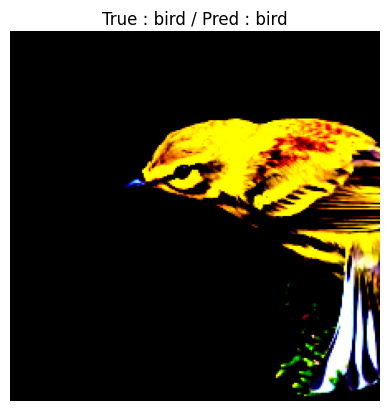

In [30]:
import matplotlib.pyplot as plt

images, labels = next(iter(test_loader))

image = images[14]
label = labels[14]

input_batch = image.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    output = model(input_batch)
    pred = torch.argmax(output, 1).item()

image_np = image.permute(1, 2, 0,).numpy()

plt.imshow(image_np)
plt.title(f'True : {test_dataset.classes[label]} / Pred : {test_dataset.classes[pred]}')
plt.axis('off')
plt.show()

### 16. 모델 저장

In [32]:
torch.save(
    model.state_dict(),
    'resnet18_bird_cat_dog.pth'
)